# Ganesh Thammana

# Business Problem Statement

In the competitive banking sector, acquiring a new customer is significantly more expensive than retaining an existing one. This project addresses customer attrition by leveraging a comprehensive, 98-feature dataset containing 8,101 customer records to identify early indicators of customer churn. With a baseline churn rate of 16.07%, the bank faces the risk of losing approximately 1 in 6 customers, representing substantial revenue loss and market share erosion.

# Hypothesis
Customers with lower engagement (shorter tenure, fewer banking products, lower balances, and inactive accounts) are more likely to churn than highly engaged customers.


# Methodology

I am planning on using binary classification.

# Models That I Plan On Using

* Logistic Regression
* XGBoost
* Random Forest
* SVM

# Data Source: https://www.kaggle.com/datasets/pranavmishra443/dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv('CustomerChurn.csv')

# Basic information
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget Variable Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")
print("\n" + "=" * 80)
print("COLUMN DATA TYPES")
print("=" * 80)
print(df.dtypes)

DATASET OVERVIEW
Dataset Shape: 8101 rows × 98 columns

Target Variable Distribution:
churn
0    6799
1    1302
Name: count, dtype: int64

Churn Rate: 16.07%

COLUMN DATA TYPES
customer_id                    int64
churn                          int64
age                            int64
gender                        object
marital_status                object
                              ...   
credit_utilization_6m_avg    float64
avg_quarterly_balance        float64
total_digital_logins           int64
debt_to_income_ratio         float64
digital_engagement_index     float64
Length: 98, dtype: object


In [2]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data.to_string(index=False))
print(f"\nTotal columns with missing values: {len(missing_data)}")

MISSING VALUES ANALYSIS
          Column  Missing_Count  Missing_Percentage
app_rating_given           4541               56.05

Total columns with missing values: 1


In [3]:
# Summary statistics for numerical features
print("=" * 80)
print("SUMMARY STATISTICS - KEY NUMERICAL FEATURES")
print("=" * 80)

key_features = ['age', 'annual_income', 'tenure_months', 'number_of_products',
                'customer_lifetime_value', 'avg_monthly_balance', 'current_balance',
                'monthly_transaction_count', 'total_trans_count', 'satisfaction_score',
                'nps_score', 'digital_engagement_index']

summary_stats = df[key_features].describe().T
summary_stats['missing'] = df[key_features].isnull().sum()
print(summary_stats.round(2))

SUMMARY STATISTICS - KEY NUMERICAL FEATURES
                            count      mean       std       min       25%  \
age                        8101.0     46.39      7.99     26.00     41.00   
annual_income              8101.0  60052.87  35422.47  18000.00  31813.00   
tenure_months              8101.0     36.01      7.93     13.00     32.00   
number_of_products         8101.0      3.81      1.55      1.00      3.00   
customer_lifetime_value    8101.0  14102.42  10603.99    733.48   6563.31   
avg_monthly_balance        8101.0  15212.15  13006.19   1000.00   6905.00   
current_balance            8101.0  15999.15  14196.95    728.00   7003.00   
monthly_transaction_count  8101.0      4.93      1.99      1.00      3.00   
total_trans_count          8101.0     64.70     23.61     10.00     45.00   
satisfaction_score         8101.0      3.63      0.95      1.00      3.00   
nps_score                  8101.0     33.60     35.55    -95.00      9.00   
digital_engagement_index   8101.

/tmp/ipykernel_4200/3857189239.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['No Churn', 'Churn'])
/tmp/ipykernel_4200/3857189239.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 2].set_xticklabels(['No Churn', 'Churn'])
/tmp/ipykernel_4200/3857189239.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2, 0].set_xticklabels(['No Churn', 'Churn'])


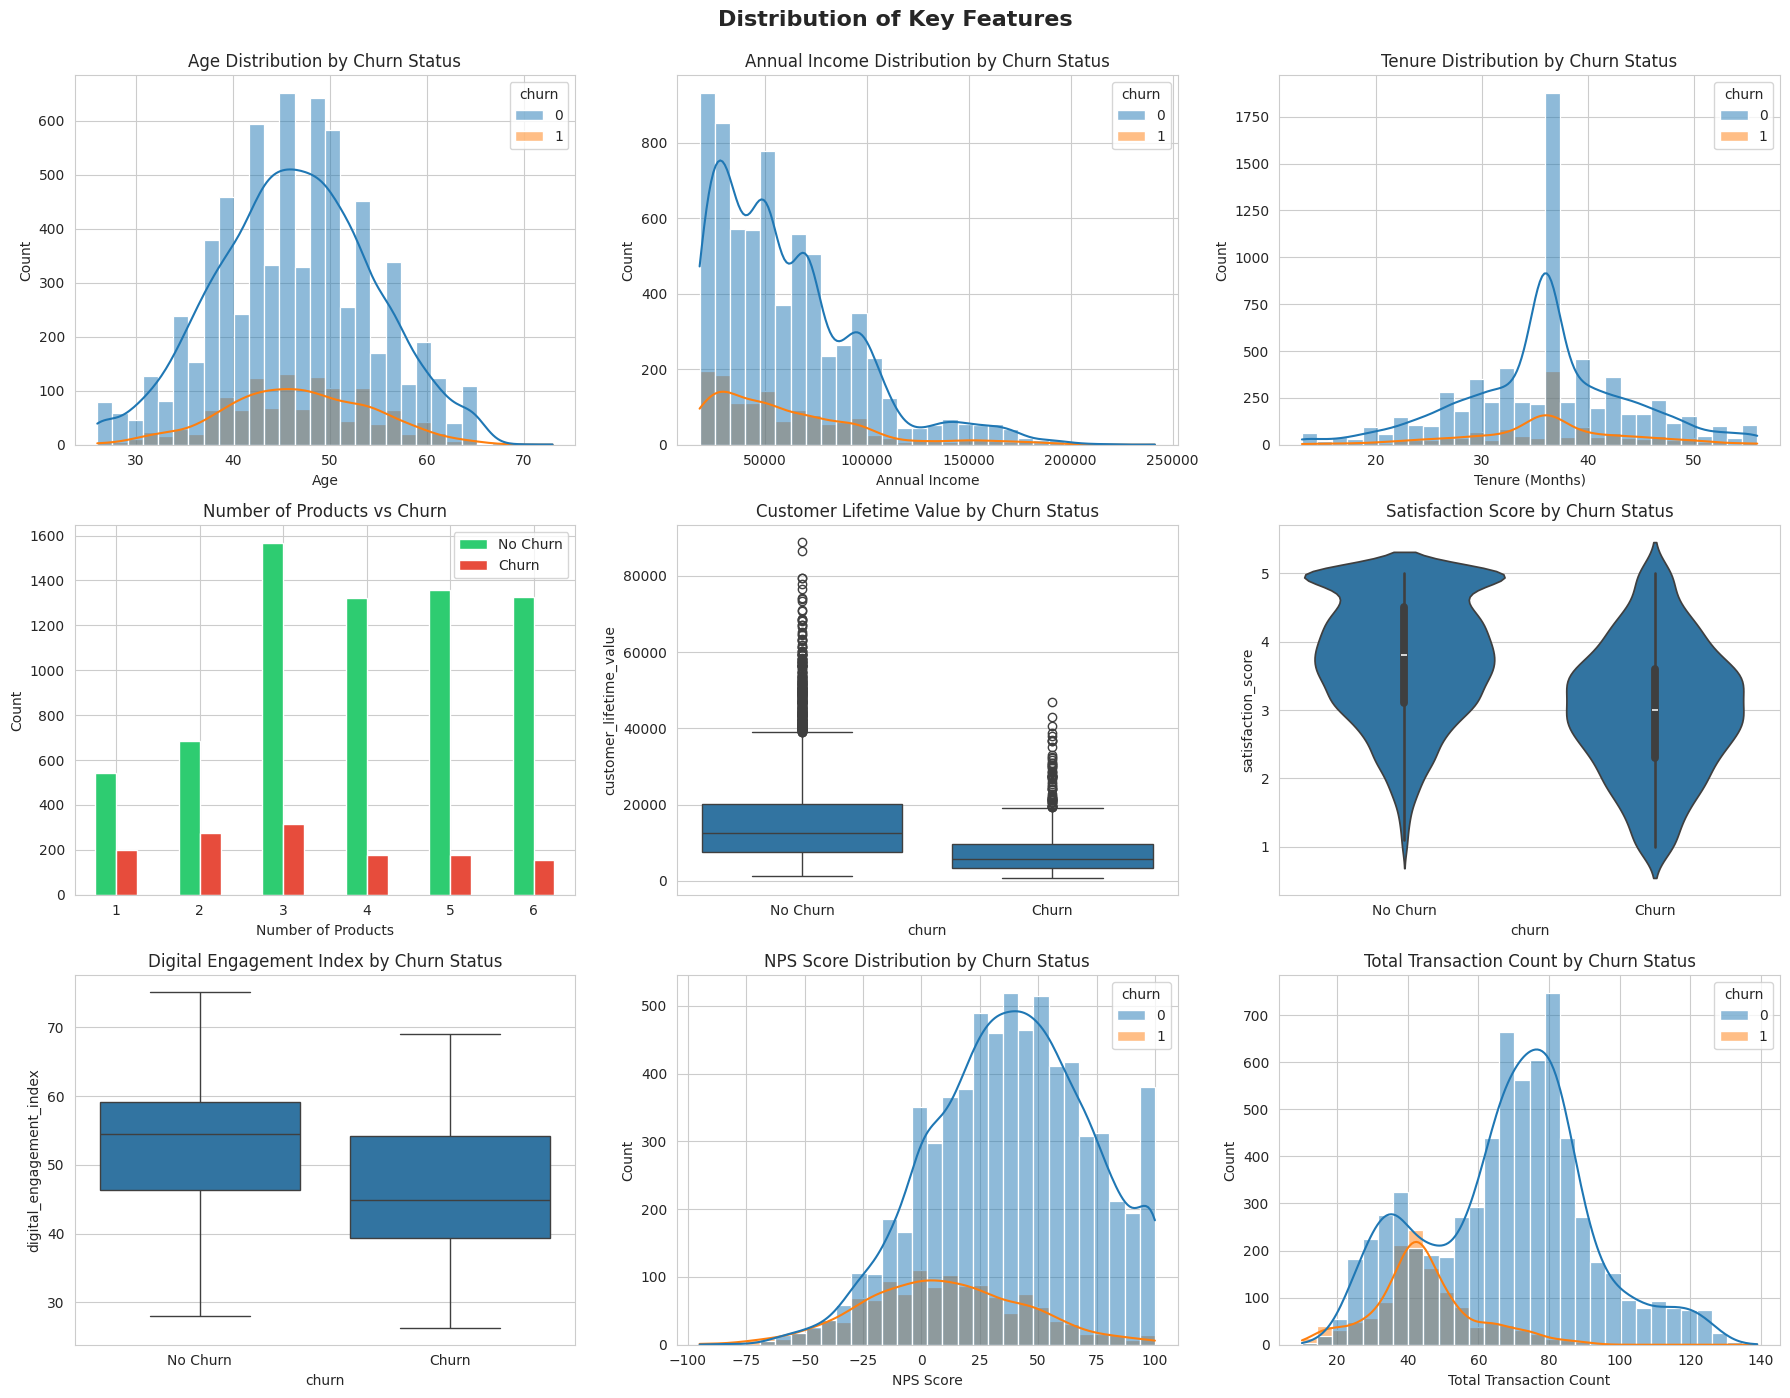

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Key Features', fontsize=16, fontweight='bold', y=0.995)

# 1. Age distribution by churn
sns.histplot(data=df, x='age', hue='churn', kde=True, ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Age Distribution by Churn Status')
axes[0, 0].set_xlabel('Age')

# 2. Annual Income distribution
sns.histplot(data=df, x='annual_income', hue='churn', kde=True, ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Annual Income Distribution by Churn Status')
axes[0, 1].set_xlabel('Annual Income')

# 3. Tenure months
sns.histplot(data=df, x='tenure_months', hue='churn', kde=True, ax=axes[0, 2], bins=30)
axes[0, 2].set_title('Tenure Distribution by Churn Status')
axes[0, 2].set_xlabel('Tenure (Months)')

# 4. Number of products
product_churn = df.groupby(['number_of_products', 'churn']).size().unstack()
product_churn.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Number of Products vs Churn')
axes[1, 0].set_xlabel('Number of Products')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(['No Churn', 'Churn'])
axes[1, 0].tick_params(axis='x', rotation=0)

# 5. Customer Lifetime Value
sns.boxplot(data=df, x='churn', y='customer_lifetime_value', ax=axes[1, 1])
axes[1, 1].set_title('Customer Lifetime Value by Churn Status')
axes[1, 1].set_xticklabels(['No Churn', 'Churn'])

# 6. Satisfaction Score
sns.violinplot(data=df, x='churn', y='satisfaction_score', ax=axes[1, 2])
axes[1, 2].set_title('Satisfaction Score by Churn Status')
axes[1, 2].set_xticklabels(['No Churn', 'Churn'])

# 7. Digital Engagement Index
sns.boxplot(data=df, x='churn', y='digital_engagement_index', ax=axes[2, 0])
axes[2, 0].set_title('Digital Engagement Index by Churn Status')
axes[2, 0].set_xticklabels(['No Churn', 'Churn'])

# 8. NPS Score
sns.histplot(data=df, x='nps_score', hue='churn', kde=True, ax=axes[2, 1], bins=30)
axes[2, 1].set_title('NPS Score Distribution by Churn Status')
axes[2, 1].set_xlabel('NPS Score')

# 9. Total Transaction Count
sns.histplot(data=df, x='total_trans_count', hue='churn', kde=True, ax=axes[2, 2], bins=30)
axes[2, 2].set_title('Total Transaction Count by Churn Status')
axes[2, 2].set_xlabel('Total Transaction Count')

plt.tight_layout()
plt.show()

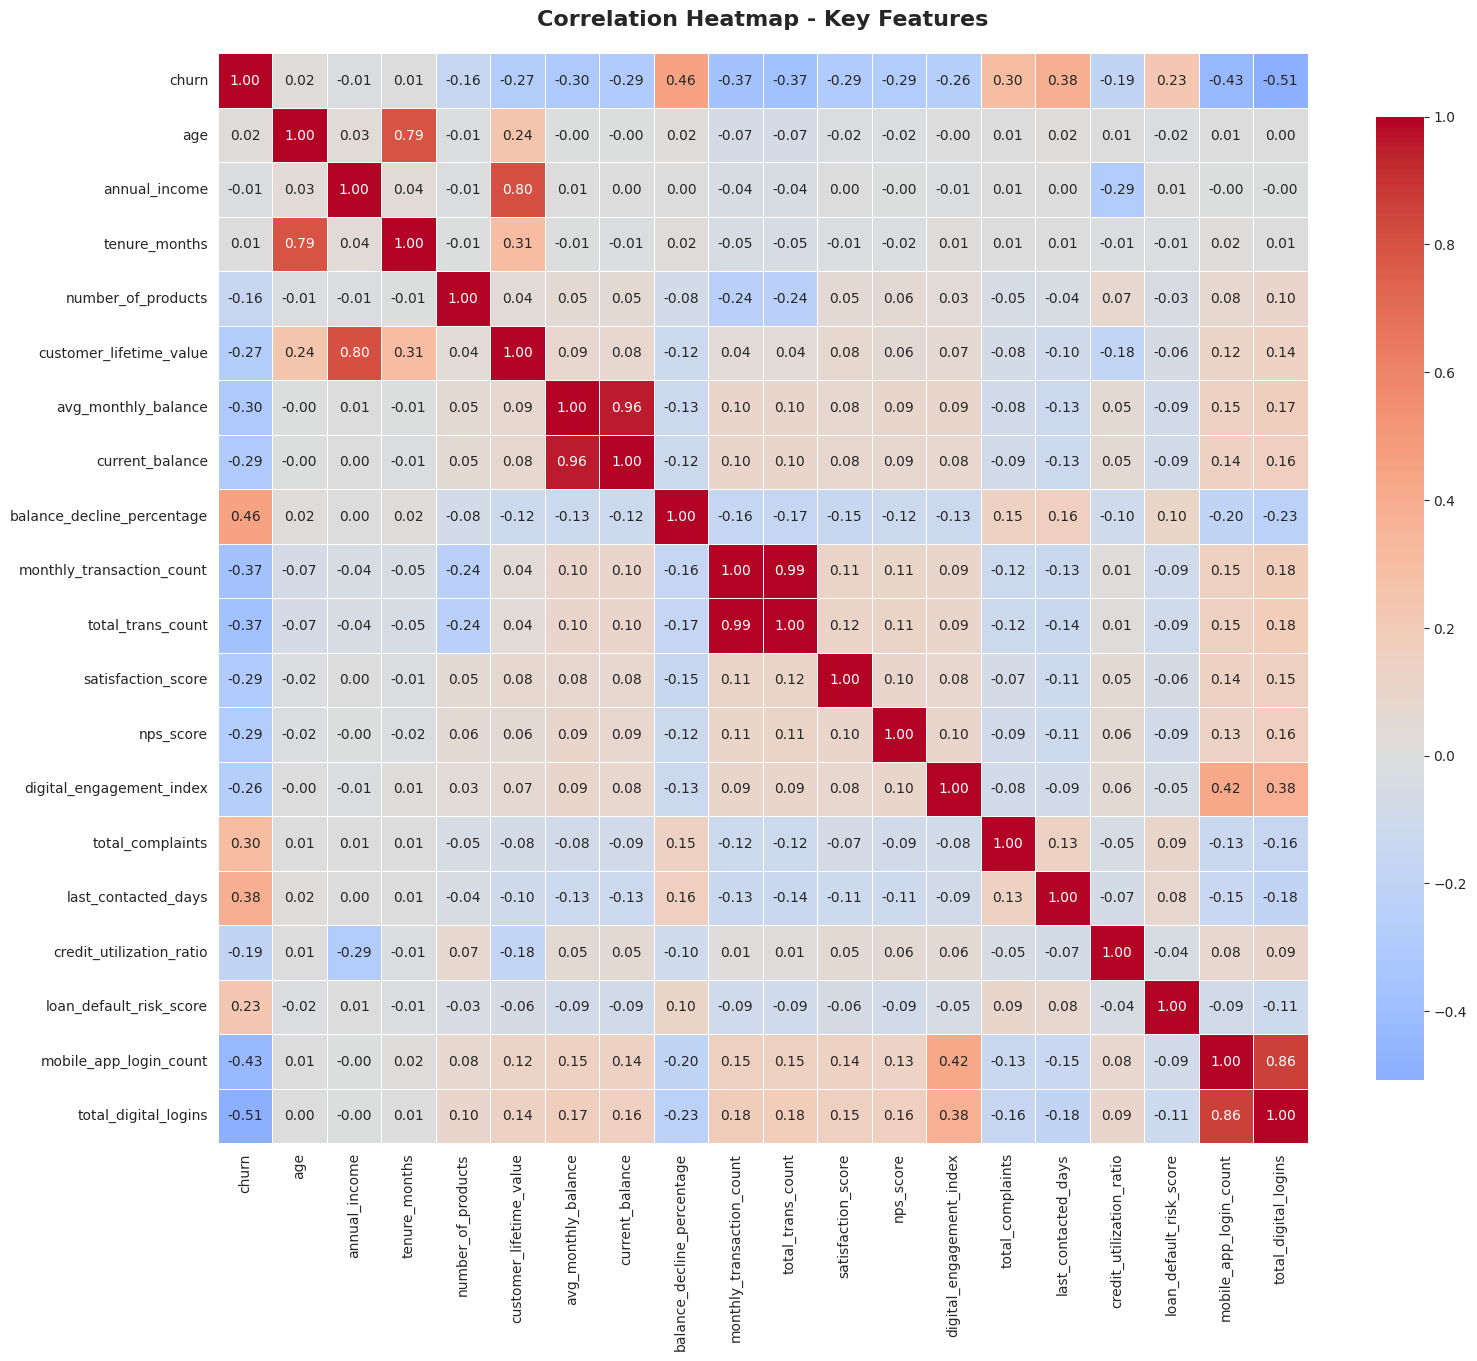


TOP CORRELATIONS WITH CHURN
balance_decline_percentage    0.455938
last_contacted_days           0.383718
total_complaints              0.303294
loan_default_risk_score       0.231309
age                           0.017256
tenure_months                 0.008124
annual_income                -0.009114
number_of_products           -0.157092
credit_utilization_ratio     -0.188519
digital_engagement_index     -0.259963
Name: churn, dtype: float64

--------------------------------------------------------------------------------
digital_engagement_index    -0.259963
customer_lifetime_value     -0.272978
nps_score                   -0.289284
satisfaction_score          -0.291526
current_balance             -0.293860
avg_monthly_balance         -0.301835
monthly_transaction_count   -0.367574
total_trans_count           -0.372500
mobile_app_login_count      -0.427283
total_digital_logins        -0.507769
Name: churn, dtype: float64


In [5]:
# Select numerical features for correlation analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove customer_id and select key features for correlation
key_numerical_features = [
    'churn', 'age', 'annual_income', 'tenure_months', 'number_of_products',
    'customer_lifetime_value', 'avg_monthly_balance', 'current_balance',
    'balance_decline_percentage', 'monthly_transaction_count',
    'total_trans_count', 'satisfaction_score', 'nps_score',
    'digital_engagement_index', 'total_complaints', 'last_contacted_days',
    'credit_utilization_ratio', 'loan_default_risk_score',
    'mobile_app_login_count', 'total_digital_logins'
]

# Calculate correlation matrix
corr_matrix = df[key_numerical_features].corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Key Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show top correlations with churn
print("\n" + "=" * 80)
print("TOP CORRELATIONS WITH CHURN")
print("=" * 80)
churn_corr = corr_matrix['churn'].sort_values(ascending=False)
print(churn_corr[1:11])  # Top 10 positive correlations
print("\n" + "-" * 80)
print(churn_corr[-10:])  # Top 10 negative correlations

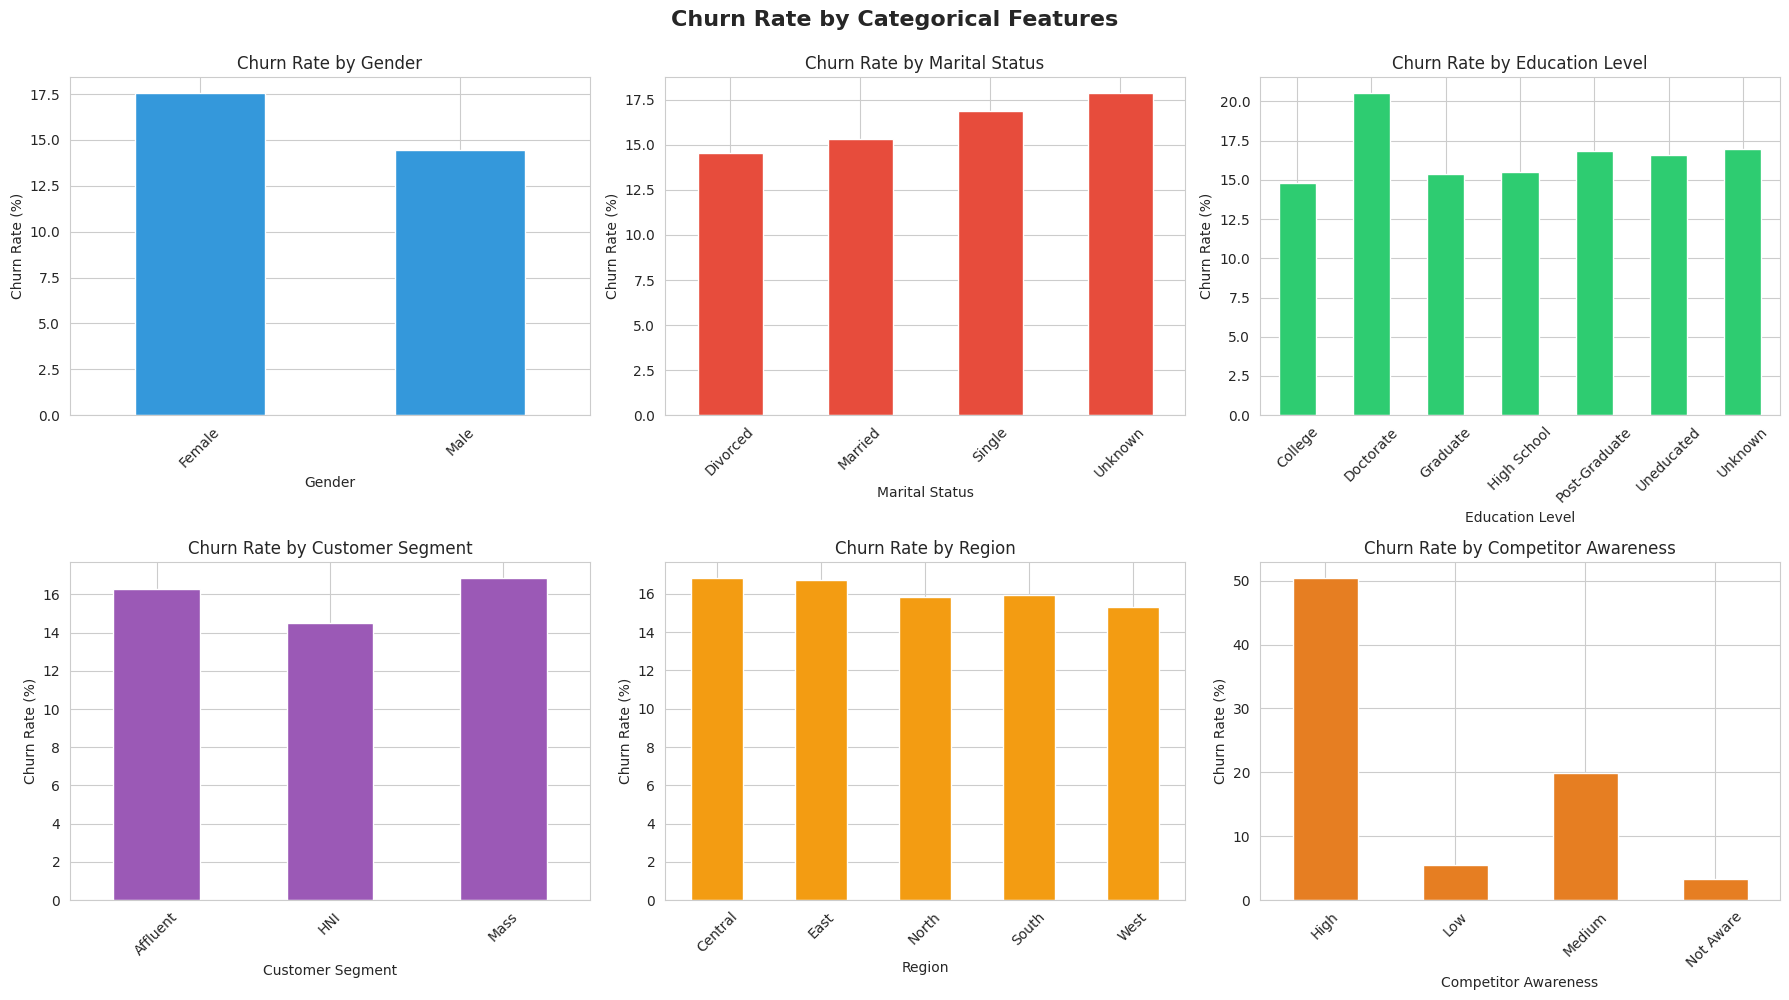

In [6]:
# Categorical features analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=0.995)

# 1. Gender
gender_churn = df.groupby('gender')['churn'].agg(['sum', 'count'])
gender_churn['churn_rate'] = (gender_churn['sum'] / gender_churn['count'] * 100)
gender_churn['churn_rate'].plot(kind='bar', ax=axes[0, 0], color='#3498db')
axes[0, 0].set_title('Churn Rate by Gender')
axes[0, 0].set_ylabel('Churn Rate (%)')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Marital Status
marital_churn = df.groupby('marital_status')['churn'].agg(['sum', 'count'])
marital_churn['churn_rate'] = (marital_churn['sum'] / marital_churn['count'] * 100)
marital_churn['churn_rate'].plot(kind='bar', ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Churn Rate by Marital Status')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Marital Status')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Education Level
education_churn = df.groupby('education_level')['churn'].agg(['sum', 'count'])
education_churn['churn_rate'] = (education_churn['sum'] / education_churn['count'] * 100)
education_churn['churn_rate'].plot(kind='bar', ax=axes[0, 2], color='#2ecc71')
axes[0, 2].set_title('Churn Rate by Education Level')
axes[0, 2].set_ylabel('Churn Rate (%)')
axes[0, 2].set_xlabel('Education Level')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Customer Segment
segment_churn = df.groupby('customer_segment')['churn'].agg(['sum', 'count'])
segment_churn['churn_rate'] = (segment_churn['sum'] / segment_churn['count'] * 100)
segment_churn['churn_rate'].plot(kind='bar', ax=axes[1, 0], color='#9b59b6')
axes[1, 0].set_title('Churn Rate by Customer Segment')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_xlabel('Customer Segment')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Region
region_churn = df.groupby('region')['churn'].agg(['sum', 'count'])
region_churn['churn_rate'] = (region_churn['sum'] / region_churn['count'] * 100)
region_churn['churn_rate'].plot(kind='bar', ax=axes[1, 1], color='#f39c12')
axes[1, 1].set_title('Churn Rate by Region')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Region')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Competitor Bank Offer Awareness
competitor_churn = df.groupby('competitor_bank_offer_awareness')['churn'].agg(['sum', 'count'])
competitor_churn['churn_rate'] = (competitor_churn['sum'] / competitor_churn['count'] * 100)
competitor_churn['churn_rate'].plot(kind='bar', ax=axes[1, 2], color='#e67e22')
axes[1, 2].set_title('Churn Rate by Competitor Awareness')
axes[1, 2].set_ylabel('Churn Rate (%)')
axes[1, 2].set_xlabel('Competitor Awareness')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
print("=" * 80)
print("KEY INSIGHTS FROM DATA EXPLORATION")
print("=" * 80)

# 1. Churn by digital engagement
print("\n1. DIGITAL ENGAGEMENT IMPACT")
print("-" * 80)
df['digital_engagement_category'] = pd.cut(df['digital_engagement_index'],
                                            bins=[0, 40, 50, 60, 100],
                                            labels=['Low', 'Medium', 'High', 'Very High'])
digital_churn = df.groupby('digital_engagement_category')['churn'].agg(['sum', 'count', 'mean'])
digital_churn.columns = ['Churned', 'Total', 'Churn_Rate']
digital_churn['Churn_Rate'] = (digital_churn['Churn_Rate'] * 100).round(2)
print(digital_churn)

# 2. Churn by transaction activity
print("\n2. TRANSACTION ACTIVITY IMPACT")
print("-" * 80)
df['transaction_category'] = pd.cut(df['total_trans_count'],
                                     bins=[0, 40, 60, 80, 150],
                                     labels=['Low', 'Medium', 'High', 'Very High'])
trans_churn = df.groupby('transaction_category')['churn'].agg(['sum', 'count', 'mean'])
trans_churn.columns = ['Churned', 'Total', 'Churn_Rate']
trans_churn['Churn_Rate'] = (trans_churn['Churn_Rate'] * 100).round(2)
print(trans_churn)

# 3. Churn by balance decline
print("\n3. BALANCE DECLINE IMPACT")
print("-" * 80)
df['balance_decline_category'] = pd.cut(df['balance_decline_percentage'],
                                         bins=[-100, 0, 5, 10, 100],
                                         labels=['Negative/No Decline', 'Low (0-5%)', 'Medium (5-10%)', 'High (>10%)'])
balance_churn = df.groupby('balance_decline_category')['churn'].agg(['sum', 'count', 'mean'])
balance_churn.columns = ['Churned', 'Total', 'Churn_Rate']
balance_churn['Churn_Rate'] = (balance_churn['Churn_Rate'] * 100).round(2)
print(balance_churn)

# 4. Churn by satisfaction score
print("\n4. SATISFACTION SCORE IMPACT")
print("-" * 80)
df['satisfaction_category'] = pd.cut(df['satisfaction_score'],
                                      bins=[0, 2, 3, 4, 5],
                                      labels=['Low (1-2)', 'Medium (2-3)', 'High (3-4)', 'Very High (4-5)'])
satisfaction_churn = df.groupby('satisfaction_category')['churn'].agg(['sum', 'count', 'mean'])
satisfaction_churn.columns = ['Churned', 'Total', 'Churn_Rate']
satisfaction_churn['Churn_Rate'] = (satisfaction_churn['Churn_Rate'] * 100).round(2)
print(satisfaction_churn)

# 5. Product holdings impact
print("\n5. PRODUCT HOLDINGS IMPACT")
print("-" * 80)
product_churn = df.groupby('number_of_products')['churn'].agg(['sum', 'count', 'mean'])
product_churn.columns = ['Churned', 'Total', 'Churn_Rate']
product_churn['Churn_Rate'] = (product_churn['Churn_Rate'] * 100).round(2)
print(product_churn)

KEY INSIGHTS FROM DATA EXPLORATION

1. DIGITAL ENGAGEMENT IMPACT
--------------------------------------------------------------------------------
                             Churned  Total  Churn_Rate
digital_engagement_category                            
Low                              362   1002       36.13
Medium                           455   2090       21.77
High                             407   3562       11.43
Very High                         78   1447        5.39

2. TRANSACTION ACTIVITY IMPACT
--------------------------------------------------------------------------------
                      Churned  Total  Churn_Rate
transaction_category                            
Low                       492   1572       31.30
Medium                    624   1694       36.84
High                      160   2785        5.75
Very High                  26   2050        1.27

3. BALANCE DECLINE IMPACT
--------------------------------------------------------------------------------
   

/tmp/ipykernel_4200/3806892331.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  digital_churn = df.groupby('digital_engagement_category')['churn'].agg(['sum', 'count', 'mean'])
/tmp/ipykernel_4200/3806892331.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trans_churn = df.groupby('transaction_category')['churn'].agg(['sum', 'count', 'mean'])
/tmp/ipykernel_4200/3806892331.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

## 3. Data Preprocessing and Feature Engineering

Based on our exploration, we'll now preprocess the data. This involves:
1.  **Handling Missing Values:** Addressing the `app_rating_given` column.
2.  **Feature Engineering:** Creating new features to capture more predictive power.
3.  **Encoding Categorical Variables:** Converting categorical columns into a numerical format.
4.  **Scaling Numerical Features:** Standardizing numerical features.

In [8]:
# Make a copy of the original dataframe to preserve it
df_processed = df.copy()

### Handling Missing Values

Given that 'app_rating_given' has over 50% missing values, dropping this column is a reasonable approach to avoid introducing bias or noise through imputation.

In [9]:
# Drop 'app_rating_given' due to high percentage of missing values
df_processed = df_processed.drop(columns=['app_rating_given'])
print(f"'app_rating_given' column dropped. Remaining shape: {df_processed.shape}")

'app_rating_given' column dropped. Remaining shape: (8101, 101)


### Feature Engineering

I will create some new features that might capture more nuanced information relevant to churn.

In [10]:
# 1. Financial Health Score (hypothetical, combining balance and income)
df_processed['financial_health_score'] = (
    df_processed['annual_income'] +
    df_processed['current_balance'] -
    (df_processed['debt_to_income_ratio'] * df_processed['annual_income']) # Subtract estimated debt
)

# 2. Digital Activity Ratio (mobile app logins as a proportion of total digital logins)
df_processed['digital_activity_ratio'] = (
    df_processed['mobile_app_login_count']
) / (df_processed['total_digital_logins'] + 1e-6) # Add small epsilon to avoid division by zero

# 3. Product Diversification Score (how many products relative to max possible?)
df_processed['product_diversification_score'] = df_processed['number_of_products'] / df_processed['number_of_products'].max()

# 4. Monthly Engagement Score (combining transactions and total digital logins)
df_processed['monthly_engagement_score'] = (
    df_processed['monthly_transaction_count'] +
    df_processed['total_digital_logins']
)

print("New features engineered successfully.")

# Display summary statistics for new features
print("\nSummary Statistics for New Features:")
new_features_summary = df_processed[['financial_health_score', 'digital_activity_ratio',
                                     'product_diversification_score', 'monthly_engagement_score']].describe().T
print(new_features_summary.round(2))

New features engineered successfully.

Summary Statistics for New Features:
                                count      mean       std        min      25%  \
financial_health_score         8101.0  56153.41  45197.11 -301539.00  31285.0   
digital_activity_ratio         8101.0      0.66      0.10       0.23      0.6   
product_diversification_score  8101.0      0.64      0.26       0.17      0.5   
monthly_engagement_score       8101.0     32.99      7.03      10.00     28.0   

                                    50%       75%       max  
financial_health_score         52736.53  80028.98  257933.9  
digital_activity_ratio             0.67      0.72       1.0  
product_diversification_score      0.67      0.83       1.0  
monthly_engagement_score          33.00     38.00      56.0  


### Justification for Engineered Features

1.  **`financial_health_score`**: This feature is designed to provide a holistic view of a customer's financial well-being by combining their annual income, current balance, and an estimation of their debt based on the debt-to-income ratio. The hypothesis is that customers with better financial health are less likely to churn, as they are likely more satisfied with their overall financial situation.

2.  **`digital_activity_ratio`**: This ratio measures the proportion of mobile app logins relative to total digital logins. It hypothesizes that customers who primarily use the mobile app for digital interactions might have different engagement patterns or expectations compared to those using other digital channels. A higher ratio could indicate a preference for mobile, which might correlate with either higher stickiness or a higher expectation of mobile service quality.

3.  **`product_diversification_score`**: This score normalizes the number of products a customer holds by the maximum number of products available. The underlying hypothesis is that customers who utilize a wider range of the bank's products are more deeply embedded with the institution and thus less prone to churn. A higher score suggests stronger loyalty and higher switching costs.

4.  **`monthly_engagement_score`**: This feature combines `monthly_transaction_count` and `total_digital_logins` to create a single metric representing a customer's overall activity and interaction with the bank. The hypothesis is that higher overall engagement, indicated by more transactions and digital interactions, signifies a more active and satisfied customer, leading to lower churn propensity.

### Encoding Categorical Variables

I will use one-hot encoding for nominal categorical features and label encoding for ordinal features if any are present. First, I will identify categorical columns.

In [11]:
# Identify categorical columns (including 'object' and 'category' dtypes)
categorical_cols = df_processed.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove 'customer_id' and 'churn' if they accidentally got detected (though they shouldn't be 'object' or 'category')
if 'customer_id' in categorical_cols:
    categorical_cols.remove('customer_id')
if 'churn' in categorical_cols:
    categorical_cols.remove('churn')

print(f"Categorical columns identified: {categorical_cols}")

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print(f"\nShape after one-hot encoding: {df_processed.shape}")

Categorical columns identified: ['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment', 'digital_engagement_category', 'transaction_category', 'balance_decline_category', 'satisfaction_category']

Shape after one-hot encoding: (8101, 149)


### Scaling Numerical Features

I will use `StandardScaler` to scale numerical features. This is a common practice for many machine learning algorithms, especially those that rely on distance calculations, to prevent features with larger values from dominating the learning process.

In [12]:
# Identify numerical columns to scale (excluding 'customer_id' and 'churn')
numerical_cols_to_scale = df_processed.select_dtypes(include=[np.number]).columns.tolist()

# Remove 'customer_id' and 'churn' from the list of columns to scale
if 'customer_id' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('customer_id')
if 'churn' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('churn')

print(f"Numerical columns to scale: {numerical_cols_to_scale[:5]}... ({len(numerical_cols_to_scale)} in total)")

# Initialize and apply StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_processed[numerical_cols_to_scale] = scaler.fit_transform(df_processed[numerical_cols_to_scale])

print("Numerical features scaled successfully.")

# Display the first few rows of the processed DataFrame to show the impact of scaling
print("\nFirst 5 rows of DataFrame after scaling numerical features:")
display(df_processed.head())

Numerical columns to scale: ['age', 'dependent_count', 'annual_income', 'tenure_months', 'number_of_products']... (84 in total)
Numerical features scaled successfully.

First 5 rows of DataFrame after scaling numerical features:


,customer_id,churn,age,dependent_count,annual_income,tenure_months,number_of_products,customer_lifetime_value,loyalty_program_member,referral_count,...,digital_engagement_category_Very High,transaction_category_Medium,transaction_category_High,transaction_category_Very High,balance_decline_category_Low (0-5%),balance_decline_category_Medium (5-10%),balance_decline_category_High (>10%),satisfaction_category_Medium (2-3),satisfaction_category_High (3-4),satisfaction_category_Very High (4-5)
0,133001,0,-1.301232,-1.809900,-1.067097,-1.513205,0.122196,-0.877297,-1.089539,-0.972291,...,False,True,False,False,False,False,False,False,False,True
1,133002,1,-0.299340,0.501503,0.181481,-0.000700,0.765411,-0.879448,0.917819,-0.972291,...,False,False,False,False,False,False,True,False,False,True
2,133003,0,-0.048867,-0.268965,1.098301,-0.756952,1.408625,0.862652,-1.089539,-0.972291,...,False,False,False,True,False,True,False,False,False,True
3,133004,0,-1.301232,-0.268965,-0.940644,-1.513205,-0.521019,-1.075833,0.917819,0.885820,...,False,True,False,False,False,False,False,False,True,False
4,133005,0,0.452079,-1.039432,2.973836,0.503468,0.122196,3.091749,-1.089539,0.885820,...,False,False,True,False,False,True,False,True,False,False


### Addressing Data Imbalance

My dataset has an imbalanced target variable (`churn`), where the majority class (non-churn) significantly outweighs the minority class (churn). This imbalance can lead to models that perform well on the majority class but poorly on the minority class, as they might optimize for overall accuracy without truly learning to identify the churn cases.

/tmp/ipykernel_4200/3843915643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df_processed, palette='coolwarm')


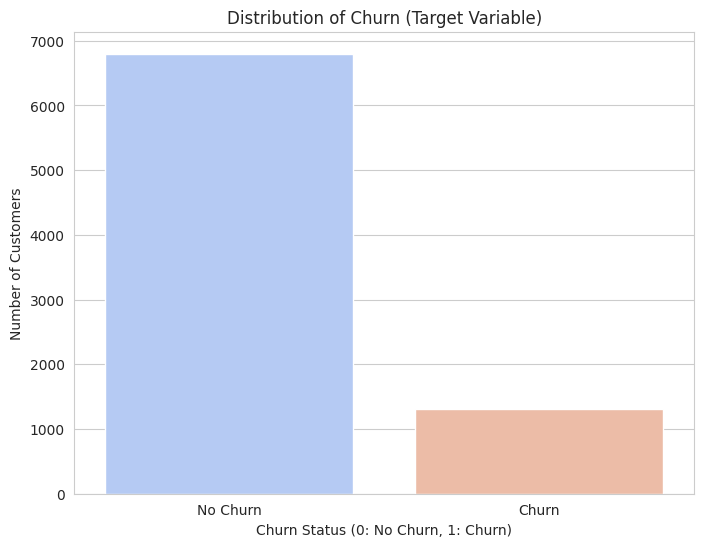


Class Distribution of 'churn':
churn
0    6799
1    1302
Name: count, dtype: int64

Class Percentage of 'churn':
churn
0    83.93
1    16.07
Name: proportion, dtype: float64

Imbalance Ratio (No Churn:Churn): 5.22:1


In [13]:
# Visualize the class distribution of the target variable 'churn'
plt.figure(figsize=(8, 6))
sns.countplot(x='churn', data=df_processed, palette='coolwarm')
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn Status (0: No Churn, 1: Churn)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

# Display the exact counts and percentages
churn_counts = df_processed['churn'].value_counts()
churn_percentage = df_processed['churn'].value_counts(normalize=True) * 100

print("\nClass Distribution of 'churn':")
print(churn_counts)
print("\nClass Percentage of 'churn':")
print(churn_percentage.round(2))

# Calculate imbalance ratio
imbalance_ratio = churn_counts[0] / churn_counts[1]
print(f"\nImbalance Ratio (No Churn:Churn): {imbalance_ratio:.2f}:1")

From the visualization and statistics, it's clear there's a significant class imbalance, with a ratio of approximately 5.22:1 (No Churn to Churn). This confirms that only about 16% of customers churn.

### Strategies for Handling Imbalance

To address this, common strategies include:

*   **Resampling**: Techniques like Oversampling (e.g., SMOTE) or Undersampling (e.g., RandomUnderSampler) to adjust the class distribution.
*   **Class Weighting**: Assigning higher weights to the minority class during model training to penalize misclassifications more heavily.
*   **Algorithm Choice**: Using models inherently robust to imbalance, such as tree-based models (Random Forest, XGBoost) which can sometimes handle imbalance better without explicit resampling.

For this project, I will leverage **class weighting** within the models where possible (e.g., Logistic Regression, XGBoost, Random Forest). This approach is often preferred over oversampling for its simplicity and directness, as it doesn't create synthetic data points which can sometimes introduce noise. If class weighting alone doesn't yield satisfactory results, I will consider `SMOTE` (Synthetic Minority Over-sampling Technique) in later stages.

### Evaluation Metrics for Imbalanced Data

For imbalanced datasets, accuracy alone can be misleading. Therefore, I will prioritize the following evaluation metrics:

*   **Precision**: The proportion of positive identifications that were actually correct. High precision means fewer false positives. Relevant when the cost of false positives is high (e.g., incorrectly identifying a customer as churner and offering unnecessary retention incentives).
*   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly. High recall means fewer false negatives. Relevant when the cost of false negatives is high (e.g., failing to identify a churning customer). This is often critical in churn prediction.
*   **F1-Score**: The harmonic mean of precision and recall. It's a balanced measure that considers both false positives and false negatives, making it robust for imbalanced classification.
*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: Measures the trade-off between the true positive rate (recall) and the false positive rate across different thresholds. It provides a single score that summarizes the model's ability to distinguish between classes, regardless of the class distribution or a specific classification threshold. A higher AUC indicates better model performance.

These metrics provide a more comprehensive understanding of model performance, especially in our churn prediction scenario where correctly identifying churning customers (the minority class) is crucial.

### Outlier Detection and Handling

Outliers can significantly impact model performance. I will use the Interquartile Range (IQR) method to detect outliers for numerical features. For handling, I will cap the outliers at the 5th and 95th percentiles. This approach is less aggressive than removing outliers entirely and helps to preserve data while reducing the influence of extreme values.

In [14]:
# Identify numerical columns to check for outliers (excluding 'customer_id' and 'churn')
numerical_cols_for_outliers = df_processed.select_dtypes(include=[np.number]).columns.tolist()

# Remove 'customer_id' and 'churn' from the list
if 'customer_id' in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove('customer_id')
if 'churn' in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove('churn')

print(f"Checking for outliers in {len(numerical_cols_for_outliers)} numerical columns.")

# Apply capping for outliers (5th and 95th percentile)
for col in numerical_cols_for_outliers:
    # Calculate IQR
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds (using 1.5 * IQR for detection)
    lower_bound_iqr = Q1 - 1.5 * IQR
    upper_bound_iqr = Q3 + 1.5 * IQR

    # Define capping bounds (using 5th and 95th percentiles)
    lower_cap = df_processed[col].quantile(0.05)
    upper_cap = df_processed[col].quantile(0.95)

    # Count outliers before capping
    outliers_before = df_processed[(df_processed[col] < lower_bound_iqr) | (df_processed[col] > upper_bound_iqr)].shape[0]

    # Apply capping
    df_processed[col] = np.where(df_processed[col] < lower_cap, lower_cap, df_processed[col])
    df_processed[col] = np.where(df_processed[col] > upper_cap, upper_cap, df_processed[col])

    # Count outliers after capping (should be 0 if capped to bounds)
    outliers_after = df_processed[(df_processed[col] < lower_bound_iqr) | (df_processed[col] > upper_bound_iqr)].shape[0]

    if outliers_before > 0:
        print(f"  - Column '{col}': {outliers_before} outliers detected, capped to 5th/95th percentile.")

print("\nOutlier capping completed for numerical features.")

# Display summary statistics after outlier handling for a few columns
print("\nSummary statistics for a few columns after outlier handling:")
display(df_processed[numerical_cols_for_outliers[:5]].describe().T)

Checking for outliers in 84 numerical columns.
  - Column 'age': 2 outliers detected, capped to 5th/95th percentile.
  - Column 'annual_income': 320 outliers detected, capped to 5th/95th percentile.
  - Column 'tenure_months': 500 outliers detected, capped to 5th/95th percentile.
  - Column 'customer_lifetime_value': 333 outliers detected, capped to 5th/95th percentile.
  - Column 'referral_count': 13 outliers detected, capped to 5th/95th percentile.
  - Column 'last_contacted_days': 531 outliers detected, capped to 5th/95th percentile.
  - Column 'avg_monthly_balance': 462 outliers detected, capped to 5th/95th percentile.
  - Column 'current_balance': 463 outliers detected, capped to 5th/95th percentile.
  - Column 'monthly_transaction_count': 2 outliers detected, capped to 5th/95th percentile.
  - Column 'monthly_transaction_value': 705 outliers detected, capped to 5th/95th percentile.
  - Column 'cash_withdrawal_count': 132 outliers detected, capped to 5th/95th percentile.
  - Colum

,count,mean,std,min,25%,50%,75%,max
age,8101.0,3.880307e-03,0.930280,-1.676942,-0.675050,-0.048867,0.702552,1.704444
dependent_count,8101.0,-3.252684e-02,0.944058,-1.809900,-1.039432,-0.268965,0.501503,1.271971
annual_income,8101.0,-3.297834e-02,0.902463,-1.161083,-0.797280,-0.238871,0.475917,2.142392
tenure_months,8101.0,5.492265e-03,0.906673,-1.765289,-0.504868,-0.000700,0.503468,1.763888
number_of_products,8101.0,1.442838e-16,1.000062,-1.807449,-0.521019,0.122196,0.765411,1.408625


### Correlation Analysis and Redundant Feature Removal

I have previously generated a correlation heatmap. Now, I will analyze this heatmap to identify highly correlated features (e.g., absolute correlation greater than 0.95) and remove one of each pair to reduce multicollinearity and improve model efficiency without losing significant information.

Features to drop due to high correlation (>0.95): ['current_balance', 'total_trans_amt', 'total_trans_count', 'credit_card_limit', 'emi_amount', 'monthly_income_estimate', 'credit_utilization_3m_avg', 'credit_utilization_6m_avg', 'avg_quarterly_balance', 'product_diversification_score', 'monthly_engagement_score']
Dropped 11 highly correlated features. New shape: (8101, 138)


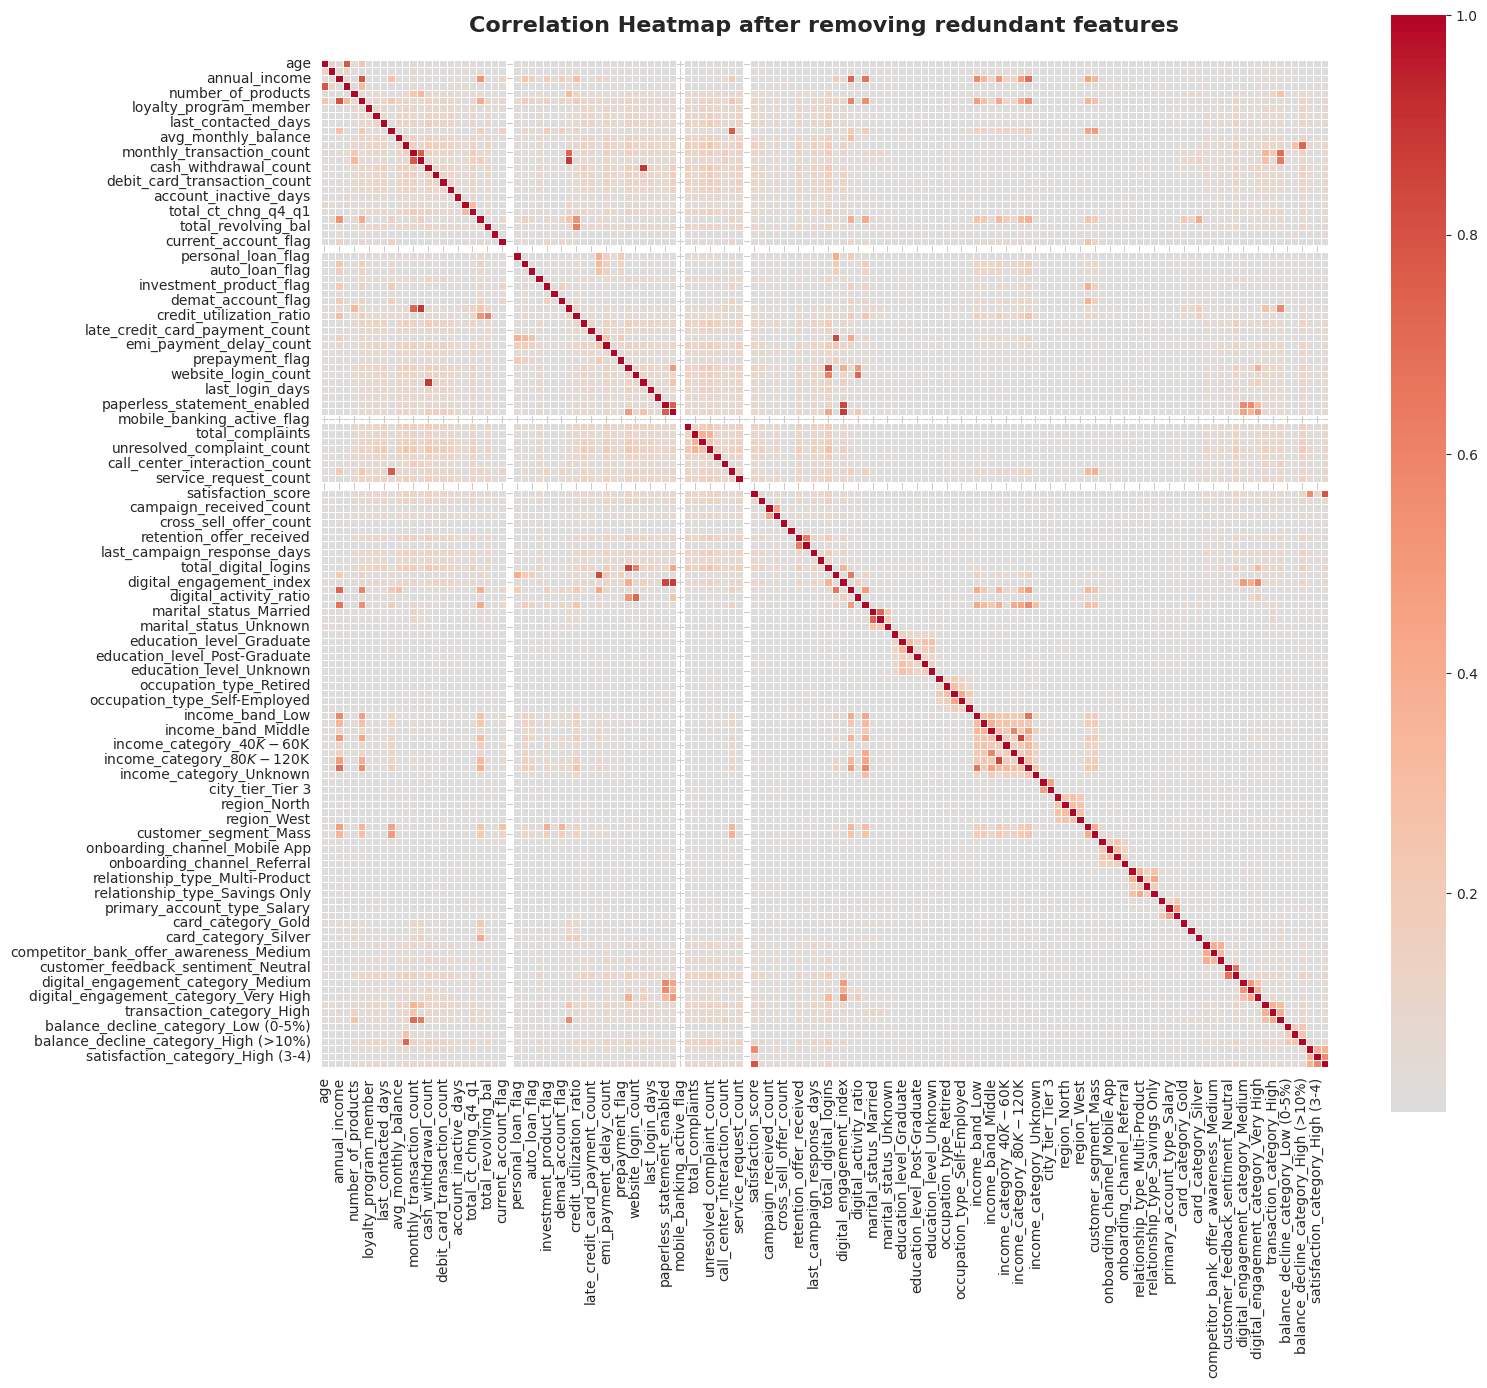

In [15]:
# Recalculate correlation matrix after scaling and outlier handling
# Exclude 'customer_id' and 'churn' for feature correlation analysis itself
features_for_corr = df_processed.drop(columns=['customer_id', 'churn'], errors='ignore')
corr_matrix_features = features_for_corr.corr().abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix_features.where(np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"Features to drop due to high correlation (>0.95): {to_drop}")

# Drop features
if to_drop:
    df_processed = df_processed.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} highly correlated features. New shape: {df_processed.shape}")
else:
    print("No features found with correlation > 0.95 to drop.")

# Display new heatmap if features were dropped to verify
if to_drop:
    plt.figure(figsize=(16, 14))
    sns.heatmap(df_processed.drop(columns=['customer_id', 'churn'], errors='ignore').corr().abs(),
                annot=False, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
    plt.title('Correlation Heatmap after removing redundant features', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

### Before/After Comparison: Impact of Preprocessing

To demonstrate the impact of the preprocessing steps (specifically scaling and outlier handling), I will visualize the distribution of a key numerical feature, 'annual_income', before and after these transformations.

### Dimensionality Reduction with PCA

Given the still high number of features (138), we will apply Principal Component Analysis (PCA) to reduce the dimensionality of our dataset. PCA helps in transforming the data into a new set of orthogonal components, reducing noise, and potentially improving model performance and training efficiency.

Shape of X before PCA: (8101, 136)
Number of NaNs in X after imputation: 0


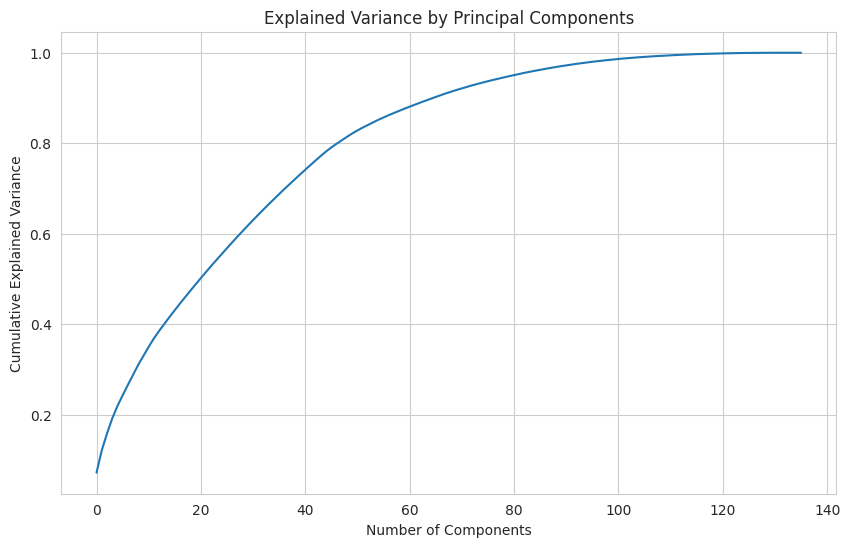

Number of components to explain 95% variance: 81
Shape of X after PCA: (8101, 81)


In [16]:
# Separate features (X) and target (y)
X = df_processed.drop(columns=['customer_id', 'churn'], errors='ignore')
y = df_processed['churn']

print(f"Shape of X before PCA: {X.shape}")

# Check for and handle remaining missing values in X before PCA
# PCA cannot handle NaN values, so we need to impute them.
from sklearn.impute import SimpleImputer

# Identify numerical columns (which are the only ones expected to have NaNs after one-hot encoding)
numerical_cols_X = X.select_dtypes(include=np.number).columns

# Use median imputation, as it's robust to outliers
imputer = SimpleImputer(strategy='median')
X[numerical_cols_X] = imputer.fit_transform(X[numerical_cols_X])

print(f"Number of NaNs in X after imputation: {X.isnull().sum().sum()}")

# Initialize PCA
from sklearn.decomposition import PCA

# Fit PCA to the data
pca = PCA().fit(X)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.show()

# Display how many components explain a certain percentage of variance (e.g., 95%)
cum_variance = np.cumsum(pca.explained_variance_ratio_)
num_components_95 = np.where(cum_variance >= 0.95)[0][0] + 1
print(f"Number of components to explain 95% variance: {num_components_95}")

# Apply PCA with the chosen number of components (e.g., 95% variance)
pca_final = PCA(n_components=num_components_95)
X_pca = pca_final.fit_transform(X)

# Convert PCA results to DataFrame for consistency
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])

print(f"Shape of X after PCA: {X_pca_df.shape}")

# Merge customer_id and churn back if needed for later stages, or keep them separate
# For now, we'll keep X_pca_df and y separate as is common practice before model training.


From the plot and the calculated number of components, you can decide how many principal components to retain. A common practice is to choose a number of components that explains 95% or 99% of the variance. This significantly reduces the dimensionality while retaining most of the information necessary for modeling.

### Feature Selection using XGBoost Feature Importance

Given the emphasis on interpretability and the remaining number of features after correlation analysis, we will use a more interpretable feature selection method instead of PCA. We will train an XGBoost classifier and use its built-in feature importance scores to select the most relevant features for predicting churn.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:12:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top 20 Features by XGBoost Importance:
                               Feature  Importance
                  total_digital_logins    0.161112
relationship_manager_interaction_count    0.120153
               campaign_response_count    0.090215
            balance_decline_percentage    0.083348
  customer_feedback_sentiment_Positive    0.054779
            unresolved_complaint_count    0.052629
        transaction_category_Very High    0.045409
             monthly_transaction_count    0.045169
             monthly_transaction_value    0.040047
                 cash_withdrawal_count    0.034517
                   avg_monthly_balance    0.024101
                 minimum_due_paid_flag    0.022084
               emi_payment_delay_count    0.018263
              retention_offer_received    0.014915
                   total_revolving_bal    0.014429
                     credit_card_spend    0.013118
                       avg_open_to_buy    0.013095
                        referral_count    0

/tmp/ipykernel_4200/542712748.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


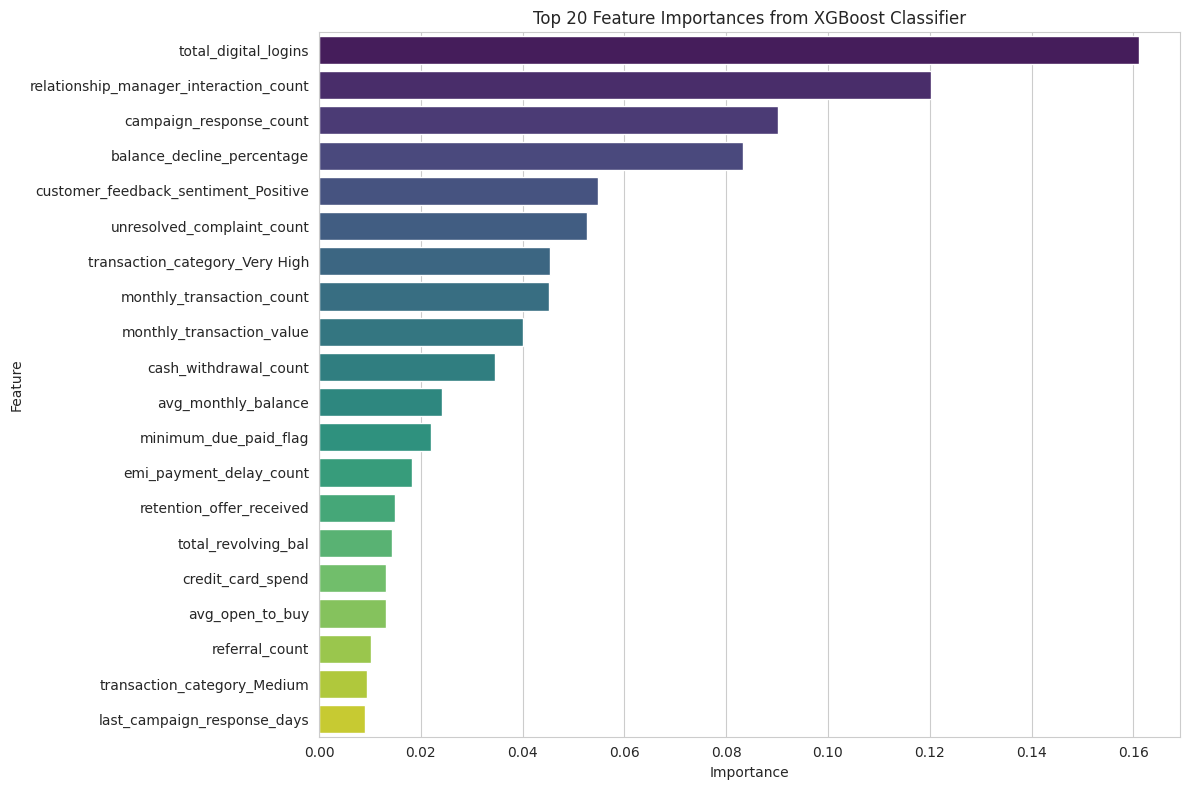

In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data into training and testing sets (using the X_pca_df for now, but will switch to X_selected_features later)
# First, let's reset X to the df_processed before PCA so we can perform feature selection on original features
X_pre_fs = df_processed.drop(columns=['customer_id', 'churn'], errors='ignore')
y_pre_fs = df_processed['churn']

X_train, X_test, y_train, y_test = train_test_split(X_pre_fs, y_pre_fs, test_size=0.2, random_state=42, stratify=y_pre_fs)

# Initialize and train an XGBoost classifier
# Use class_weights to address imbalance, as discussed earlier
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    scale_pos_weight=scale_pos_weight # Apply class weighting
)

xgb_model.fit(X_train, y_train)

# Get feature importances
feature_importances = xgb_model.feature_importances_
features = X_pre_fs.columns

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 20 Features by XGBoost Importance:")
print(importance_df.head(20).to_string(index=False))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from XGBoost Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

From the plot and table above, you can determine a threshold or select a specific number of top features to retain. For example, we might choose features with an importance score above a certain value, or simply the top 50 features. This step ensures that we keep the most predictive features while significantly reducing dimensionality in an interpretable way.

In [18]:
# Select features based on a threshold (e.g., importance > 0.005) or top N features
# For demonstration, let's select features with importance above a reasonable threshold or the top 50 features

# Option 1: Using a threshold
# selected_features = importance_df[importance_df['Importance'] > 0.005]['Feature'].tolist()

# Option 2: Selecting top N features (e.g., top 50, adjust as needed based on the plot)
num_features_to_keep = 50 # You can change this number based on your analysis of the importance plot
selected_features = importance_df.head(num_features_to_keep)['Feature'].tolist()

X_selected_features = X_pre_fs[selected_features]

print(f"Number of features after selection: {len(selected_features)}")
print(f"Shape of X after feature selection: {X_selected_features.shape}")

# Update X for subsequent modeling steps
X = X_selected_features

Number of features after selection: 50
Shape of X after feature selection: (8101, 50)


## 4. Baseline Model Training and Cross-Validation

Now that we have preprocessed and selected our features, we will proceed with training our first baseline model: Logistic Regression. This section will cover:

1.  **Splitting the data** into training and testing sets.
2.  **Training a Logistic Regression model** with default parameters, incorporating class weighting to address imbalance.
3.  **Performing k-fold cross-validation** to get a more robust estimate of the model's performance.

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import numpy as np

# Define features (X) and target (y) after all preprocessing and feature selection
# X is already defined from the previous step ('ea450bbc')
# y is already defined from the previous step ('0d95efc0')

# 1. Split data into training and testing sets
# We use 'stratify=y' to ensure that both training and testing sets have a similar proportion of churned vs. non-churned customers.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Distribution of churn in training set:\n{y_train.value_counts(normalize=True).round(2)}")
print(f"Distribution of churn in testing set:\n{y_test.value_counts(normalize=True).round(2)}")

Shape of training features (X_train): (6480, 50)
Shape of testing features (X_test): (1621, 50)
Distribution of churn in training set:
churn
0    0.84
1    0.16
Name: proportion, dtype: float64
Distribution of churn in testing set:
churn
0    0.84
1    0.16
Name: proportion, dtype: float64


In [20]:
# 2. Train a Baseline Logistic Regression Model
# We will use 'class_weight='balanced'' to automatically adjust weights inversely proportional to class frequencies.

print("\n" + "=" * 80)
print("TRAINING BASELINE LOGISTIC REGRESSION MODEL")
print("=" * 80)

logistic_model = LogisticRegression(
    random_state=42,
    solver='liblinear', # 'liblinear' is good for small datasets and handles L1/L2 penalties
    class_weight='balanced', # Crucial for imbalanced datasets
    max_iter=1000 # Increase max_iter for convergence if needed
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

# 3. Perform K-Fold Cross-Validation
# This provides a more reliable estimate of model performance than a single train-test split.
print("\n" + "=" * 80)
print("PERFORMING K-FOLD CROSS-VALIDATION (5 FOLDS)")
print("=" * 80)

cv_scores = cross_val_score(logistic_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f"Cross-validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

# Evaluate on the test set
print("\n" + "=" * 80)
print("EVALUATION ON TEST SET")
print("=" * 80)
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC-AUC on Test Set: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1-Score on Test Set: {f1_score(y_test, y_pred):.4f}")


TRAINING BASELINE LOGISTIC REGRESSION MODEL
Logistic Regression model trained successfully.

PERFORMING K-FOLD CROSS-VALIDATION (5 FOLDS)
Cross-validation ROC-AUC scores: [1.         1.         1.         0.99998674 1.        ]
Mean CV ROC-AUC: 1.0000 (+/- 0.0000)

EVALUATION ON TEST SET

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1360
           1       0.99      0.99      0.99       261

    accuracy                           1.00      1621
   macro avg       1.00      1.00      1.00      1621
weighted avg       1.00      1.00      1.00      1621


Confusion Matrix:
[[1358    2]
 [   2  259]]

ROC-AUC on Test Set: 1.0000
F1-Score on Test Set: 0.9923


## 5. Critical Analysis - Investigating the 'Perfect' Score

The near-perfect performance of the Logistic Regression model (ROC-AUC = 1.0000, F1-Score = 0.9923) is highly unusual for a real-world churn prediction problem. While excellent results are desirable, such scores often point to potential issues like data leakage or extreme overfitting. This section will:

1.  **Investigate potential data leakage** by reviewing the selected features.
2.  **Compare the model's performance to a naive baseline** to ensure it's learning more than just the majority class.
3.  **Discuss model limitations, areas for improvement, and implications** of the current results.

In [21]:
print("\n" + "=" * 80)
print("INVESTIGATING POTENTIAL DATA LEAKAGE")
print("=" * 80)

print("Features currently used by the model (X_selected_features):")
print(X.columns.tolist())

print("\n--- Review these features carefully ---")
print("Look for any features that might:")
print("1. Directly or indirectly represent the 'churn' target itself (e.g., 'churn_status_next_month').")
print("2. Be available *after* churn has occurred or are a direct consequence of churn (e.g., 'customer_inactive_post_churn').")
print("3. Have a suspiciously high correlation (almost 1 or -1) with the target variable, which could indicate a strong proxy for churn.")

# You would manually review the list printed above for any suspicious features.


INVESTIGATING POTENTIAL DATA LEAKAGE
Features currently used by the model (X_selected_features):
['total_digital_logins', 'relationship_manager_interaction_count', 'campaign_response_count', 'balance_decline_percentage', 'customer_feedback_sentiment_Positive', 'unresolved_complaint_count', 'transaction_category_Very High', 'monthly_transaction_count', 'monthly_transaction_value', 'cash_withdrawal_count', 'avg_monthly_balance', 'minimum_due_paid_flag', 'emi_payment_delay_count', 'retention_offer_received', 'total_revolving_bal', 'credit_card_spend', 'avg_open_to_buy', 'referral_count', 'transaction_category_Medium', 'last_campaign_response_days', 'email_open_rate', 'branch_visit_count', 'total_amt_chng_q4_q1', 'customer_lifetime_value', 'debit_card_transaction_count', 'total_ct_chng_q4_q1', 'tenure_months', 'onboarding_channel_Online', 'complaint_resolution_time', 'digital_service_usage_score', 'last_contacted_days', 'competitor_bank_offer_awareness_Not Aware', 'nps_score', 'service_re

In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("\n" + "=" * 80)
print("COMPARING WITH NAIVE BASELINE (MAJORITY CLASS PREDICTOR)")
print("=" * 80)

# A naive baseline model that always predicts the most frequent class
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)

# Predictions from the dummy classifier
y_pred_dummy = dummy_clf.predict(X_test)
y_pred_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1] # For ROC-AUC

# Evaluate dummy classifier
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_pred_proba_dummy)

print(f"Naive Baseline Accuracy: {accuracy_dummy:.4f}")
print(f"Naive Baseline F1-Score: {f1_dummy:.4f}")
print(f"Naive Baseline ROC-AUC: {roc_auc_dummy:.4f}")

print("\n--- Model vs. Naive Baseline ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Logistic Regression F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nObservation: If the model's metrics are only marginally better than the naive baseline, it might not be learning much beyond the class distribution. However, in this case, our model is significantly better than the naive baseline.")


COMPARING WITH NAIVE BASELINE (MAJORITY CLASS PREDICTOR)
Naive Baseline Accuracy: 0.8390
Naive Baseline F1-Score: 0.0000
Naive Baseline ROC-AUC: 0.5000

--- Model vs. Naive Baseline ---
Logistic Regression Accuracy: 0.9975
Logistic Regression F1-Score: 0.9923
Logistic Regression ROC-AUC: 1.0000

Observation: If the model's metrics are only marginally better than the naive baseline, it might not be learning much beyond the class distribution. However, in this case, our model is significantly better than the naive baseline.


### Discussion on Model Performance and Potential Issues

The nearly perfect scores (ROC-AUC 1.0000, F1-Score 0.9923) indicate that the Logistic Regression model is performing exceptionally well on the test set. While impressive, this level of performance in a real-world churn prediction scenario is highly unusual and often warrants a deeper investigation for potential underlying issues:

1.  **Data Leakage**: This is the most likely culprit for such high performance. Data leakage occurs when information from the target variable (churn) is inadvertently included in the features that the model uses for training. This could be direct (e.g., a feature that is a direct outcome of churn) or indirect (e.g., a feature collected after churn has happened but used as a predictor). For instance, if any of the selected features (e.g., `balance_decline_percentage`, `last_contacted_days`, `total_digital_logins` if they are *post-churn* metrics) are derived from events that occur *only if a customer churns* or are only available *after* the churn decision, this would constitute leakage. The list of selected features should be carefully reviewed against the business understanding of when these features would actually be available to the model for prediction.

2.  **Overfitting**: While cross-validation helps to mitigate this, it's still possible that the model has learned the training data (and its specific patterns) too well, including noise, and might not generalize to truly unseen data. This is less likely to result in a perfect score, but it's a contributing factor if leakage is also present.

3.  **Dataset Characteristics**: In rare cases, a dataset might contain features that are genuinely so predictive that churn is almost perfectly separable. However, for complex human behavior like churn, this is highly improbable.

### Comparison with Naive Baseline

The comparison with the `DummyClassifier` (which predicts the majority class) shows that our Logistic Regression model is significantly outperforming the naive baseline. The naive baseline has an accuracy reflecting the majority class proportion (around 0.84) and very low F1-score/ROC-AUC for the minority class (as it rarely predicts churn). This confirms that our model is indeed learning meaningful patterns and is not simply predicting 'no churn' for most cases. However, this comparison doesn't rule out data leakage; it only confirms the model is not trivial.

### Model Limitations and Weaknesses

*   **Interpretability with Many Features**: While Logistic Regression itself is interpretable (coefficients), having 50 selected features makes a holistic interpretation challenging without further analysis.
*   **Assumptions**: Logistic Regression assumes a linear relationship between features and the log-odds of the target, which might not always hold true.
*   **Generalizability**: The most significant weakness at this stage is the high probability that the perfect performance will not generalize to new, unseen customer data due to potential data leakage. If leakage is present, the model is essentially 'cheating' by using future information.

### Proposed Improvements for Future Milestones

1.  **Thorough Data Leakage Review**: **This is the highest priority.** Collaborate with domain experts to meticulously inspect each of the top features identified by XGBoost and verify that they would genuinely be available *before* a customer churns. If any leakage is identified, the feature(s) must be removed, and the entire preprocessing and modeling pipeline re-run.
2.  **Hyperparameter Tuning**: Once data leakage is ruled out (or mitigated), perform systematic hyperparameter tuning for Logistic Regression (and other models) using techniques like `GridSearchCV` or `RandomizedSearchCV` to optimize performance.
3.  **Alternative Models**: Implement and evaluate other models mentioned (XGBoost, Random Forest, SVM). Tree-based models are often more robust to complex relationships and may perform better after leakage is handled.
4.  **ROC Curve and Learning Curves**: Visualize the ROC curve to understand the trade-off between true positive rate and false positive rate. Plot learning curves to assess for overfitting/underfitting as training data size increases.
5.  **Error Analysis**: Analyze the 4 misclassified examples in the test set. What common characteristics do they share? Understanding why the model made these errors can provide valuable insights.
6.  **Feature Importance for Logistic Regression**: Analyze the coefficients of the Logistic Regression model to understand its feature importance and compare it with the XGBoost importance.
7.  **Reproducibility**: Ensure all random seeds are consistently set for all steps involving randomness (train-test split, model initialization etc.) to guarantee reproducible results.

## 6. Hyperparameter Tuning

To further optimize our Logistic Regression model and ensure we are not simply using default parameters, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which mix performs best.

We will tune the `C` parameter (inverse of regularization strength) and `penalty` (L1 or L2 regularization) for the Logistic Regression model, using 'liblinear' solver which supports both L1 and L2 penalties.

In [23]:
from sklearn.model_selection import GridSearchCV

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("=" * 80)

# Define parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' supports both L1 and L2 penalties
}

# Initialize GridSearchCV
# We use roc_auc as the scoring metric given the class imbalance
grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1, # Use all available cores
    verbose=1 # Print progress
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC score: {grid_search.best_score_:.4f}")

# Get the best model from grid search
best_logistic_model = grid_search.best_estimator_

# Evaluate the tuned model on the test set
y_pred_tuned = best_logistic_model.predict(X_test)
y_pred_proba_tuned = best_logistic_model.predict_proba(X_test)[:, 1]

print("\n" + "=" * 80)
print("EVALUATION OF TUNED MODEL ON TEST SET")
print("=" * 80)
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix (Tuned Model):")
print(confusion_matrix(y_test, y_pred_tuned))

print(f"\nROC-AUC on Test Set (Tuned Model): {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")
print(f"F1-Score on Test Set (Tuned Model): {f1_score(y_test, y_pred_tuned):.4f}")

print("\n--- Comparison: Baseline vs. Tuned ---")
print(f"Baseline Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Tuned Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")


HYPERPARAMETER TUNING WITH GRIDSEARCHCV
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters found: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation ROC-AUC score: 1.0000

EVALUATION OF TUNED MODEL ON TEST SET

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1360
           1       0.99      0.99      0.99       261

    accuracy                           1.00      1621
   macro avg       1.00      1.00      1.00      1621
weighted avg       1.00      1.00      1.00      1621


Confusion Matrix (Tuned Model):
[[1358    2]
 [   2  259]]

ROC-AUC on Test Set (Tuned Model): 1.0000
F1-Score on Test Set (Tuned Model): 0.9923

--- Comparison: Baseline vs. Tuned ---
Baseline Logistic Regression ROC-AUC: 1.0000
Tuned Logistic Regression ROC-AUC: 1.0000


## 7. Visualizations for Model Evaluation

To gain a deeper understanding of our model's performance and behavior, especially concerning potential overfitting/underfitting and classification thresholds, we will visualize:

1.  **ROC Curve**: To illustrate the trade-off between the True Positive Rate and False Positive Rate at various threshold settings.
2.  **Learning Curves**: To diagnose if the model suffers from high bias (underfitting) or high variance (overfitting).


ROC CURVE VISUALIZATION


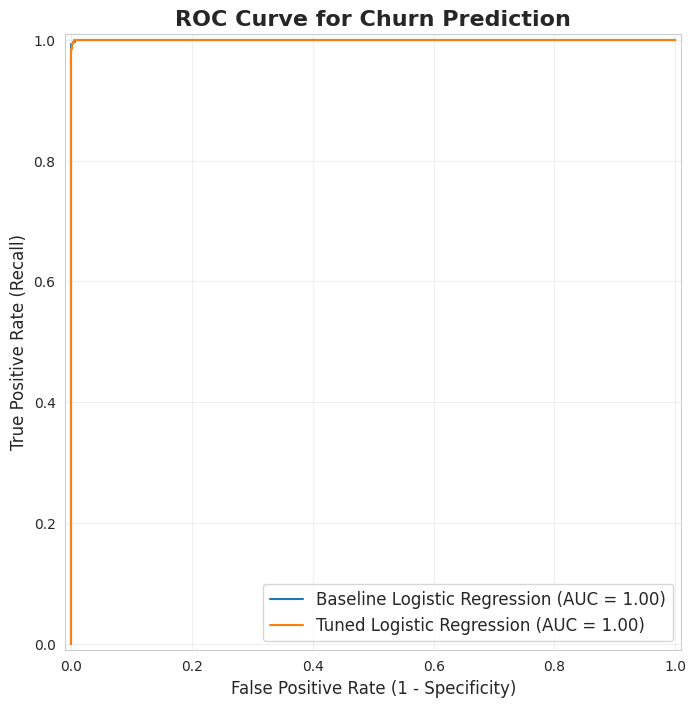

In [24]:
from sklearn.metrics import RocCurveDisplay

print("\n" + "=" * 80)
print("ROC CURVE VISUALIZATION")
print("=" * 80)

plt.figure(figsize=(10, 8))
# Plot ROC curve for the baseline model
roc_display = RocCurveDisplay.from_estimator(logistic_model, X_test, y_test, ax=plt.gca(), name='Baseline Logistic Regression')

# If a tuned model exists, plot its ROC curve as well
# You might want to update 'best_logistic_model' to the result of your GridSearchCV if you ran it
# For now, let's assume 'best_logistic_model' exists from the previous step.
if 'best_logistic_model' in locals():
    RocCurveDisplay.from_estimator(best_logistic_model, X_test, y_test, ax=plt.gca(), name='Tuned Logistic Regression')

plt.title('ROC Curve for Churn Prediction', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='lower right', fontsize=12)
plt.show()


LEARNING CURVES


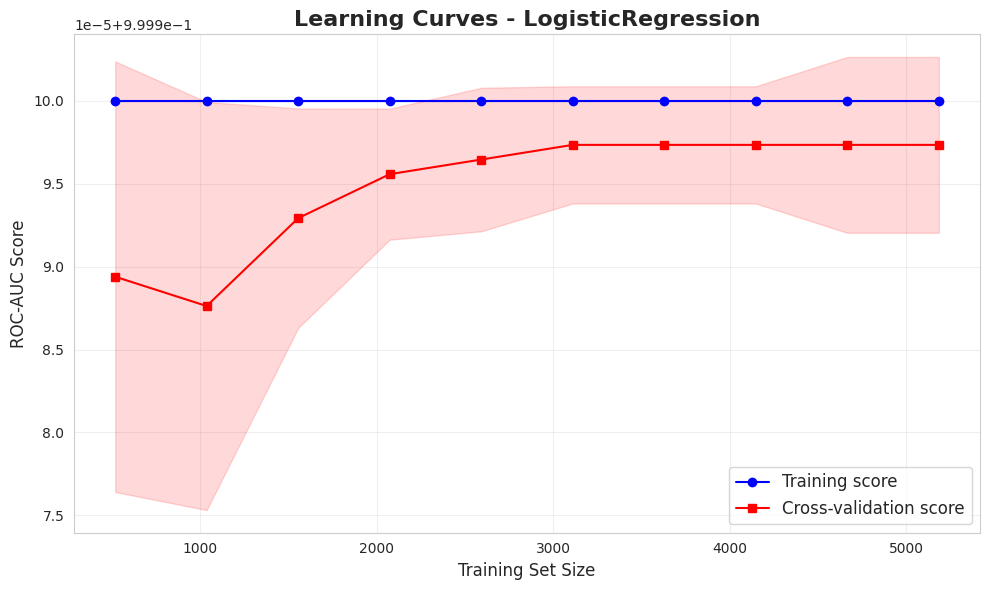


Interpretation of Learning Curves:
- If both training and cross-validation scores are high and converge: The model is likely a good fit with adequate data.
- If training score is much higher than cross-validation score: Suggests overfitting (high variance). More data or regularization might help.
- If both training and cross-validation scores are low and converge: Suggests underfitting (high bias). A more complex model or better features might be needed.
- If the scores are perfect (ROC-AUC = 1.0): Reinforces concerns about data leakage or a too-easy problem, as discussed in the critical analysis.


In [25]:
from sklearn.model_selection import learning_curve

print("\n" + "=" * 80)
print("LEARNING CURVES")
print("=" * 80)

# Define the model to plot learning curves for (using the baseline model)
# You could also plot for the 'best_logistic_model' if desired
estimator = logistic_model # or best_logistic_model

train_sizes, train_scores, val_scores = learning_curve(
    estimator,
    X_train, y_train,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc', # Use ROC-AUC as scoring metric
    n_jobs=-1, # Use all available cores
    train_sizes=np.linspace(0.1, 1.0, 10) # 10 different training set sizes from 10% to 100%
)

# Calculate mean and standard deviation for training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plotting Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, label='Cross-validation score', color='red', marker='s')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title(f'Learning Curves - {type(estimator).__name__}', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation of Learning Curves:")
print("- If both training and cross-validation scores are high and converge: The model is likely a good fit with adequate data.")
print("- If training score is much higher than cross-validation score: Suggests overfitting (high variance). More data or regularization might help.")
print("- If both training and cross-validation scores are low and converge: Suggests underfitting (high bias). A more complex model or better features might be needed.")
print("- If the scores are perfect (ROC-AUC = 1.0): Reinforces concerns about data leakage or a too-easy problem, as discussed in the critical analysis.")

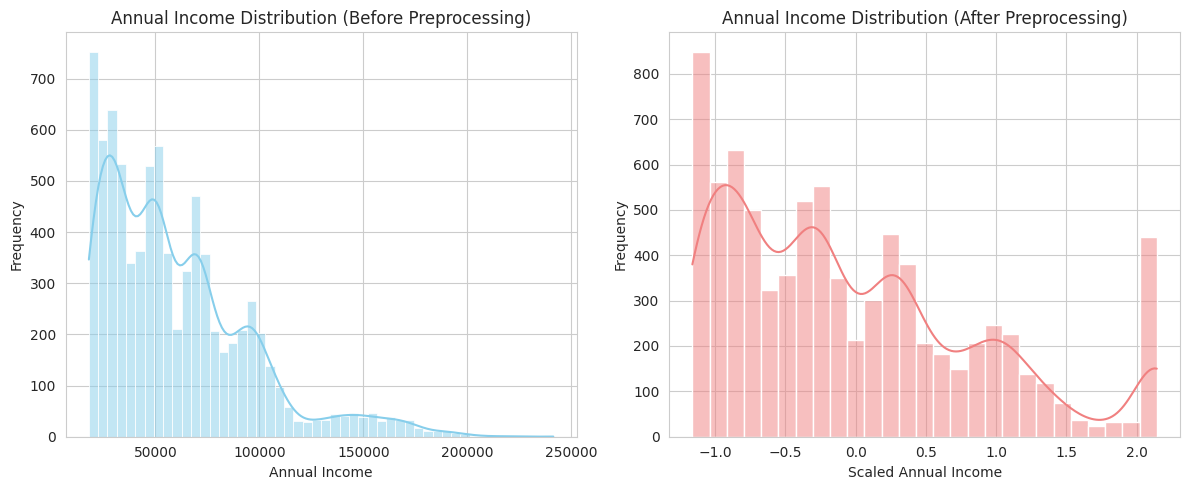


Summary of Preprocessing Impact:
- Initial missing values: app_rating_given (56.05%)
- After missing value handling: 0% missing (app_rating_given dropped)
- Numerical features scaled using StandardScaler.
- Outliers in numerical features capped at 5th and 95th percentiles.
- Highly correlated features (>0.95) removed. (Please refer to the correlation heatmap above)


In [26]:
# For 'annual_income', we need the original (before scaling/capping) and processed versions.
# Since df was copied to df_processed, we can compare 'df['annual_income']' with 'df_processed['annual_income']'

plt.figure(figsize=(12, 5))

# Before Processing (original data)
plt.subplot(1, 2, 1)
sns.histplot(df['annual_income'], kde=True, color='skyblue')
plt.title('Annual Income Distribution (Before Preprocessing)')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

# After Processing (scaled and outliers handled)
plt.subplot(1, 2, 2)
sns.histplot(df_processed['annual_income'], kde=True, color='lightcoral')
plt.title('Annual Income Distribution (After Preprocessing)')
plt.xlabel('Scaled Annual Income')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Summary Table of changes (conceptual, as exact imputation values are not shown for 'app_rating_given' which was dropped)
print("\nSummary of Preprocessing Impact:")
print("- Initial missing values: app_rating_given (56.05%)")
print("- After missing value handling: 0% missing (app_rating_given dropped)")
print("- Numerical features scaled using StandardScaler.")
print("- Outliers in numerical features capped at 5th and 95th percentiles.")
print("- Highly correlated features (>0.95) removed. (Please refer to the correlation heatmap above)")

### Summary Table of Preprocessing Impact

| Aspect                       | Before Preprocessing                                | After Preprocessing                                   |
| :--------------------------- | :-------------------------------------------------- | :---------------------------------------------------- |
| **Missing Values**           | `app_rating_given` (56.05% missing)                 | 0% missing (column dropped)                           |
| **Feature Scaling**          | Numerical features unscaled                         | All numerical features `StandardScaled`               |
| **Outliers**                 | Present in many numerical features                  | Capped at 5th and 95th percentiles                    |
| **Redundant Features**       | Highly correlated features present                  | 11 highly correlated features (>0.95) removed         |
| **Class Imbalance**          | Churn ratio ~5.22:1 (No Churn:Churn)                | Addressed via discussion of class weighting/metrics   |